In [1]:
import numpy as np
import scipy.io as sio
import os
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
import random
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LinearRegression
from scipy.stats import norm
from sklearn import svm
from scipy.linalg import solve
from scipy.stats import pearsonr, spearmanr

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
seed = 1
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)


In [3]:
#create pandas dataframe from data

In [4]:
df_sessions_m1_phase1 = {}

monkey = 2

directory = '/home/dvoina/myproj1/pooya_data/M' + str(monkey) + '_Phase2_Hf_gratings/'
files = [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
files_split = [f.split('_') for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]

In [5]:
new_files = []
for i, f in enumerate(files_split):
    new_files.append([])
    new_files[i].append(int(f[0][1:]))
    new_files[i].append(int(f[1][1:]))
new_files = np.array(new_files)

In [6]:
n_sessions = len(np.unique(np.array(new_files[:, 1])))
n_sessions

2

In [7]:
list_of_stim = ["circ", "circ", "rad", "rad"]*7
list_of_snr = [1.0]*4 + [0.8]*4 + [0.65]*4 + [0.5]*4 + [0.35]*4 + [0.2]*4 + [0.05]*4
list_of_pos = ["R", "L"] * 14

In [8]:
def get_neuron_rows(n, filename):
    mat_contents = sio.loadmat(directory + filename)

    #print("NEURON N", n)
    total_rows = 0
    list_of_stim_ = [1 if list_of_stim[i] == "circ" else 0 for i in range(len(list_of_stim)) ]

    rows = []
    for trial in range(28):

        #print("trial", trial)
        spikes = mat_contents["Spike_mat"][0][trial]["spikes"]
        errors = mat_contents["Spike_mat"][0][trial]["errors"]
        rt = mat_contents["Spike_mat"][0][trial]["saccade_t"]
        
        n_trials = spikes.shape[0]
        #print("n_trials", n_trials)

        for t in range(n_trials):
            
            if errors[t][0] == 0:
                choice = list_of_stim_[trial]
            else:
                choice = 1 - list_of_stim_[trial]
                
            rows.append({
                "neuron_id": n,
                "spike_ts": np.array(spikes[t,:]).flatten(),
                "firing": np.array(spikes[t,:]).flatten()[500:750].sum(), #/(850-500),
                "stim": list_of_stim[trial],
                "snr": list_of_snr[trial],
                "pos": list_of_pos[trial],
                "error": errors[t][0],
                "choice": choice,
                "reaction_time": rt[t][0],
                "trial": total_rows
            })

            total_rows += 1

    #print("total_rows", total_rows)
    return rows

dict_of_neurons = {}
for session in np.unique(new_files[:, 1]):
    ind_s = np.where(new_files[:, 1] == session)[0]
    neurons = new_files[ind_s, 0]
    dict_of_neurons[str(session)] = neurons
    
    #print("neuron number", neurons, len(neurons))
    files_s = [files[i] for i in ind_s]
    #print("session", session, neurons, files_s)

    all_rows = []
    for n, filename in zip(neurons, files_s):
        all_rows.extend(get_neuron_rows(n, filename))
        #print("len all rows", len(all_rows))
        
    df_sessions_m1_phase1[str(session)] = pd.DataFrame(all_rows, columns=["neuron_id", "spike_ts", "firing", "stim", "snr", "pos", "error", "choice", "reaction_time", "trial"])
    

In [9]:
correct_choice = [1 if df_sessions_m1_phase1["3"][df_sessions_m1_phase1["3"].snr.isin([0.65,0.8,1.0])].stim.iloc[i] == "circ" else 0 for i in range(len(df_sessions_m1_phase1["3"][df_sessions_m1_phase1["3"].snr.isin([0.65,0.8,1.0])].stim)) ]
real_choice = df_sessions_m1_phase1["3"][df_sessions_m1_phase1["3"].snr.isin([0.65,0.8,1.0])].choice

(correct_choice - real_choice).sum()/len(correct_choice)

KeyError: '3'

In [11]:
def find_tuned_neurons(df, session, snr_list=[1.0, 0.8, 0.65, 0.5, 0.35, 0.2, 0.05]):
    
    neurons = np.unique(df[str(session)].neuron_id.values)
    neurons_tuned_circ = []
    neurons_tuned_rad = []
    neurons_untuned = []
    
    for n in neurons:

        circular_firings = []
        radial_firings = []
        for SNR in snr_list:
            circular = df_sessions_m1_phase1[str(session)][(df[str(session)].stim == 'circ') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == n)]
            radial = df_sessions_m1_phase1[str(session)][(df[str(session)].stim == 'rad') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == n)]

            #print(len(circular.firing.values), len(radial.firing.values))
            
            circular_firings += list(circular.firing.values)
            radial_firings += list(radial.firing.values)

        stat, p_value = mannwhitneyu(circular_firings, radial_firings, alternative='two-sided')
        
        """
        if p_value<=0.05:
            if np.array(circular_firings).mean() > np.array(radial_firings).mean():
                neurons_tuned_circ.append(n)
            else:       
                neurons_tuned_rad.append(n)
        else:
            neurons_untuned.append(n)
        """
        stat, p_value1 = mannwhitneyu(circular_firings, radial_firings, alternative='greater')
        stat, p_value2 = mannwhitneyu(radial_firings, circular_firings, alternative='greater')
        stat, p_value = mannwhitneyu(radial_firings, circular_firings, alternative='two-sided')
        #print("p value", p_value, np.array(circular_firings).mean(), np.array(radial_firings).mean())
        print("p_values", p_value1, p_value2)
        
        if p_value1<=0.05:
                neurons_tuned_circ.append(n)
        if p_value2<=0.05:       
                neurons_tuned_rad.append(n)
        if (p_value1 > 0.05) and (p_value2 >0.05):
            neurons_untuned.append(n)
    return neurons_tuned_circ, neurons_tuned_rad, neurons_untuned

neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, 1, snr_list=[1])
tunings = [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned]
neurons_tuned_circ, neurons_tuned_rad, neurons_untuned

p_values 0.00859537773042702 0.991942702992214
p_values 0.0008058849710954308 0.9992588374844978
p_values 0.8741309016355462 0.13062493873935493
p_values 0.14834012120945617 0.8569044898028131
p_values 0.8721833502896783 0.13288842854267596


([1, 2], [], [3, 4, 5])

In [12]:
#Q1:What is the imbalance? in toy model: 80% versus 20%

total_neuron_number = 0
total_number_tuned_circular = 0
total_number_tuned_radial = 0
total_number_untuned = 0

number_tuned_circular = []
number_tuned_radial = []
number_untuned = []

neuron_id_tuned_circular = []
neuron_id_tuned_radial = []
neuron_id_tuned_untuned = []

percentage_of_interest_circ_vs_rad = []
percentage_of_interest_stim_vs_untuned = []

for session in range(1,n_sessions+1):
    print("session", session)
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session, snr_list=[1.0])

    print(neurons_tuned_circ)
    print(neurons_tuned_rad)
    print(neurons_untuned)
    total_number_tuned_circular += len(neurons_tuned_circ)
    total_number_tuned_radial += len(neurons_tuned_rad)
    total_number_untuned += len(neurons_untuned)

    number_tuned_circular.append(len(neurons_tuned_circ))
    number_tuned_radial.append(len(neurons_tuned_rad))
    number_untuned.append(len(neurons_untuned))

    neurons_tuned_circ = np.array(neurons_tuned_circ) + total_neuron_number
    neurons_tuned_rad = np.array(neurons_tuned_rad) + total_neuron_number
    neurons_untuned = np.array(neurons_untuned) + total_neuron_number

    neuron_id_tuned_circular += list(neurons_tuned_circ)
    neuron_id_tuned_radial += list(neurons_tuned_rad)
    neuron_id_tuned_untuned += list(neurons_untuned)
    
    total_neuron_number += len(neurons_tuned_circ) + len(neurons_tuned_rad) + len(neurons_untuned)
    
    if len(neurons_tuned_circ) + len(neurons_tuned_rad) != 0:
        percentage_of_interest_circ_vs_rad.append(len(neurons_tuned_circ)/(len(neurons_tuned_circ) + len(neurons_tuned_rad)))
    else:
        percentage_of_interest_circ_vs_rad.append(0)
    percentage_of_interest_stim_vs_untuned.append((len(neurons_tuned_circ) + len(neurons_tuned_rad))/(len(neurons_tuned_circ) + len(neurons_tuned_rad) + len(number_untuned)))
    

session 1
p_values 0.00859537773042702 0.991942702992214
p_values 0.0008058849710954308 0.9992588374844978
p_values 0.8741309016355462 0.13062493873935493
p_values 0.14834012120945617 0.8569044898028131
p_values 0.8721833502896783 0.13288842854267596
[1, 2]
[]
[3, 4, 5]
session 2
p_values 0.21933561516396094 0.7875377244372557
p_values 0.9507257453877417 0.05162451627079165
p_values 0.20348743878738446 0.8028783928322643
p_values 0.8228379375122459 0.18316623299233853
[]
[]
[1, 2, 3, 4]


In [13]:
#neuron_id_tuned_circular_just1 = neuron_id_tuned_circular.copy()
#neuron_id_tuned_radial_just1 = neuron_id_tuned_radial.copy()

print("total neuron number: ", total_neuron_number)
print(neuron_id_tuned_circular, neuron_id_tuned_radial, neuron_id_tuned_untuned)
print(len(neuron_id_tuned_circular), len(neuron_id_tuned_radial), len(neuron_id_tuned_untuned))
#print(neuron_id_tuned_circular_just1, neuron_id_tuned_radial_just1)

total neuron number:  9
[1, 2] [] [3, 4, 5, 6, 7, 8, 9]
2 0 7


In [14]:
print(total_number_tuned_circular, total_number_tuned_radial, total_number_untuned)
print(total_number_tuned_circular/(total_number_tuned_circular + total_number_tuned_radial))
print((total_number_tuned_circular + total_number_tuned_radial)/(total_number_tuned_circular + total_number_tuned_radial + total_number_untuned))

2 0 7
1.0
0.2222222222222222


In [15]:
#prepare dataset on which to do Oja
#there are 93 neurons. For each one, FIX one stimulus and one SNR

In [16]:
snr_choice = [0.65, 0.8, 1.0] #[0.05, 0.2, 0.35, 0.5] #[0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 1.0]

In [17]:
df_all_sessions_m1_phase1 = pd.DataFrame([], columns=["neuron_id", "spike_ts", "firing", "stim", "snr", "pos", "error", "choice", "reaction_time", "trial"])
session_n = pd.DataFrame([], columns=["session"])

total_neurons = 0
for session in range(1,n_sessions+1):
    df_sessions_m1_phase1[str(session)].loc[:, 'neuron_id'] = df_sessions_m1_phase1[str(session)].neuron_id.copy() + total_neurons
    total_neurons += len(np.unique(np.array(df_sessions_m1_phase1[str(session)].neuron_id)))
    
    df_all_sessions_m1_phase1 = pd.concat([df_all_sessions_m1_phase1, df_sessions_m1_phase1[str(session)]], axis=0)
    session_n = pd.concat([session_n, pd.DataFrame([session]*len(df_sessions_m1_phase1[str(session)].neuron_id.values), columns=["session"])], axis=0)

df_all_sessions_m1_phase1 = pd.concat([df_all_sessions_m1_phase1, session_n], axis=1)

/tmp/ipykernel_1155107/3995063769.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all_sessions_m1_phase1 = pd.concat([df_all_sessions_m1_phase1, df_sessions_m1_phase1[str(session)]], axis=0)


In [18]:
def train_oja_unsupervised(features, student_w_init = None, add_bias=False):

    n_samples = features.shape[0]
    n_total = features.shape[1]
    rand_ind = np.random.permutation(np.arange(n_samples))
    features = features[rand_ind, :];
    if add_bias:
        features = features - features.mean(0)
    
    if student_w_init is not None:
        student_w = student_w_init
    else:
        student_w = torch.ones(1, n_total) * 0.01 #torch.randn(1, n_total) * 0.01
        
    print("student_w", student_w)
    student_b = torch.ones(1)
    eta = 0.0001
    print("eta", eta, student_w.mean())
    
    acc_arr = []; 
    print("Student learning via Oja's Rule...")
    with torch.no_grad():
        for j in range(1000):
            print("j", j)
            y_arr = []
            for i in range(features.shape[0]):
                x_i = features[i].squeeze().unsqueeze(0)

                if add_bias:
                    y_student = torch.matmul(student_w, x_i.T)[0].item() + student_b
                else:
                     y_student = torch.matmul(student_w, x_i.T)[0].item()
                dw = eta * (y_student * x_i - (y_student**2) * student_w)
                student_w += dw

                
                #learn bias
                y_new = torch.matmul(student_w, x_i.T)[0].item() + student_b
                ybar = y_new #(1 - alpha) * ybar + alpha * y_new
                student_b += eta*(-ybar) #y_target=0
                
                if np.isnan(student_w.sum()):
                    print("hello")
                    return

                #if i%100:
                #    print("student_b", student_b)
    #y_new = torch.matmul(student_w, features.T)
    #student_b = y_new.mean()
    return student_w, student_b, eta

In [19]:
def compute_cp(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y = "model", animal_choice = None, min_per_choice=6, min_wrong=3, force_ge_half=False, eps=1e-8):

    # features: (T, N) or (1,T,N) etc -> make (T, N)
    X = features.squeeze()
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = np.asarray(X)
    
    y = np.asarray(y.squeeze())
    n_stim = 2

    # logits + choice
    out = (student_w @ X.T + student_b)
    
    if isinstance(out, torch.Tensor):
        out = out.detach().cpu().numpy()
    out = np.asarray(out).ravel()

    threshold = 0.0   #if crit == "MSE" else 0.0
    choice = (out >= threshold).astype(int)
    
    if crit != "BCE":
        choice = 2*choice - 1

    if choose_y != "model":
        choice = animal_choice

    # allocate by LOOP INDEX (safe)
    CP_arr = np.full((len(student_w), n_stim), np.nan)
    new_tunings = []

    list_of_stim = [0, 1] if crit == "BCE" else [-1, 1]
    neurons_tuned_list = np.sort(np.array(list(tunings[0]) + list(tunings[1]) + list(tunings[2])))
    
    for n in range(n_neurons):

        pref = 1          
        #pref = (0 if crit == "BCE" else -1) if n in neurons_tuned_stim0 else (1)  
        for s in list_of_stim:
            
            idx = np.where(y == s)[0]
            if idx.size == 0:
                continue

            r_raw = X_np[idx, n]                  # raw firing rates this condition
 
            # FIX 4: z-score within condition to remove mean stimulus drive
            mu, sd = r_raw.mean(), r_raw.std()
            r = (r_raw - mu) / (sd + eps) if sd > eps else r_raw - mu
            
            o = (choice[idx] == pref).astype(int)  # labels: 1 = preferred choice
                
            n1 = int(o.sum())
            n0 = int((1 - o).sum())
            print("choice is preferred, or unpreferred", n0, n1)
            wrong = np.sum(choice[idx] != y[idx])
            print("wrong", wrong)

            if n1 < min_per_choice or n0 < min_per_choice or wrong < min_wrong:
               print("OH nooo, the classifier i just too good and doesn't make mistakes")
               continue

            print("o", "r", o, r)
            auc = roc_auc_score(o, r)  # <-- correct order
            print("auc", auc, 1-auc)
            if force_ge_half:
                auc = max(auc, 1 - auc)

            s_idx = 0 if s in (-1, 0) else 1
            CP_arr[n, s_idx] = auc

    cp = np.nanmean(CP_arr, axis=1)  # mean across stim, per sampled neuron
    return cp, CP_arr, neurons_tuned_list, new_tunings

def compute_noise_corr(features, y, neurons, zclip=3.0, eps=1e-8):
    X = np.asarray(features.squeeze())[:, neurons]          # (T, K)
    stim = np.asarray(y).ravel()

    Z = np.empty_like(X, dtype=float)

    # z-score within stimulus condition (removes mean/scale per stimulus)
    for s in np.unique(stim):
        idx = np.where(stim == s)[0]
        mu = X[idx].mean(axis=0)
        sd = X[idx].std(axis=0) + eps
        Z[idx] = (X[idx] - mu) / sd

    # ±3 SD trimming (their rule; easiest is drop trials with any extreme value)
    keep = np.all(np.abs(Z) <= zclip, axis=1)
    Z = Z[keep]

    # Pearson correlation matrix across neurons
    # (np.corrcoef uses columnwise corr if rowvar=False)
    C = np.corrcoef(Z, rowvar=False)              # (K, K)
    return C, Z

def compute_readout_weights(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y = "model", animal_choice = None, eps=1e-7, normalize = False):

    cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y, animal_choice)
    print("neurons_tuned_list", neurons_tuned_list)
    C, Z = compute_noise_corr(features, y, neurons_tuned_list)

    C = np.asarray(C, dtype=float)
    cp = np.asarray(cp, dtype=float).ravel()

    try:
        diag = np.clip(np.diag(C), eps, None)
    except:
        diag = np.clip(np.diag([C]), eps, None)

    rhs  = (np.pi * np.sqrt(diag) * (cp - 0.5)) / np.sqrt(2) #np.sqrt(diag) * (cp - 0.5)
    
    # Solve C beta = v  (preferred over inv(C) @ v)
    try:
        beta = solve(C, rhs, assume_a="sym") #rhs
    except np.linalg.LinAlgError:
        beta, *_ = np.linalg.lstsq(C, rhs, rcond=None)

    if normalize:
        denom = np.sqrt(beta.T @ C @ beta) + eps
        beta = beta / denom

    return beta


In [20]:
def find_bias_simple(p, student_w, student_b, features, y, crit="BCE", comparison="heuristic"):
        print("p", p)
        mean = features.clone().mean(0).numpy()
        features_sparse = features.squeeze().numpy().copy() #- mean
        m, n = features_sparse.shape
        
        for i in range(m):
            rand_zeros = np.random.choice(n, size=int(p*n), replace=False)
            features_sparse[i,rand_zeros] = 0
            #print(list(set(rand_zeros) & set(neurons_circ_new)), student_w[list(set(rand_zeros) & set(neurons_circ_new))], features[i,list(set(rand_zeros) & set(neurons_circ_new))], student_w[list(set(rand_zeros) & set(neurons_circ_new))].dot(features[i,list(set(rand_zeros) & set(neurons_circ_new))]))

        #features_sparse = features_sparse - mean #features_sparse.mean(0)
    
        logits = torch.matmul(student_w, torch.from_numpy(features_sparse.T)) + student_b
        logits_nonsparse = torch.matmul(student_w, features.T) + student_b
    
        y = y.squeeze(); logits = logits.squeeze(); logits_nonsparse = logits_nonsparse.squeeze();
        
        if comparison == "heuristic":
            ind0 = np.where(y == 0)[0] 
            ind1 = np.where(y == 1)[0]
        else:
            print('hello')
            ind0 = np.where(y == -1)[0] 
            ind1 = np.where(y == 1)[0] 

        if crit == "BCE":
            ind0 = np.where(y == 0)[0] 
            ind1 = np.where(y == 1)[0] 

        y_res = logits.detach().numpy() - student_b.item()
        """
        plt.figure()
        plt.plot(y_res[ind0])
        plt.plot(y_res[ind1])
        plt.plot(-student_b * np.ones(len(y)))
        plt.xlabel("trials")
        plt.ylabel("output of model")
        plt.legend(["trials, stim 0 (under-rep)", "trials, stim 1 (over-rep)"])
        plt.show()
        """
        print("criteria is: ", crit)
        if crit == "BCE":
            threshold = 0.0
            acc1 = ( (y[logits < threshold] == 0).sum() + (y[logits > threshold] == 1).sum() )/len(y)
            acc2 = ( (y[logits > threshold] == 0).sum() + (y[logits < threshold] == 1).sum() )/len(y)

            acc1_nonsparse = ( (y[logits_nonsparse < threshold] == 0).sum() + (y[logits_nonsparse > threshold] == 1).sum() )/len(y)
            acc2_nonsparse = ( (y[logits_nonsparse > threshold] == 0).sum() + (y[logits_nonsparse < threshold] == 1).sum() )/len(y)

        elif crit == "MSE":
            threshold = 0.0
            acc1 = ( (y[logits < threshold] == -1).sum() + (y[logits > threshold] == 1).sum() )/len(y)
            acc2 = ( (y[logits > threshold] == -1).sum() + (y[logits < threshold] == 1).sum() )/len(y)

            acc1_nonsparse = ( (y[logits_nonsparse < threshold] == -1).sum() + (y[logits_nonsparse > threshold] == 1).sum() )/len(y)
            acc2_nonsparse = ( (y[logits_nonsparse > threshold] == -1).sum() + (y[logits_nonsparse < threshold] == 1).sum() )/len(y)

        print("acc1, acc2", acc1, acc2)
        if acc1 == acc2:
            print("given p=", str(p) + ", then accuracy is: ", acc2)
            return acc2, (logits>threshold).sum()
            
        if acc1_nonsparse < acc2_nonsparse: #student_w.mean()< 0: #
            print("given p=", str(p) + ", then accuracy is: ", acc2, "class 1 labels (under-represented)", (logits>=threshold).sum(), "class 2 labels (over-represented)", (logits<threshold).sum())
            print("means of classes: ", logits[ind0].mean(), logits[ind1].mean())
            print("std of classes: ", logits[ind0].std(), logits[ind1].std())
            return acc2, (logits>=threshold).sum()
        else:
            print("given p=", str(p) + ", then accuracy is: ", acc1, "class 1 labels (under-represented)", (logits<=threshold).sum(), "class 2 labels (over-represented)", (logits>threshold).sum())
            print("means of classes: ", logits[ind0].mean(), logits[ind1].mean())
            print("std of classes: ", logits[ind0].std(), logits[ind1].std())
            return acc1, (logits<=threshold).sum()


In [21]:
def create_X_and_y(choice, df_all_sessions_m1_phase1, snr_choice, session=None):
        
        if choice == "ensamble":
            n_neurons = len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == "circ") & (df_all_sessions_m1_phase1.snr == snr_choice)].neuron_id.unique())
            list_of_neurons = df_all_sessions_m1_phase1.neuron_id.unique()
            n_trials = 1000
         
            list_of_stim = ["circ", "rad"]
            list_of_stim = list_of_stim * (n_trials//len(list_of_stim))
        
            print(np.sort(list_of_neurons))
        
            X_train = np.zeros((n_trials, n_neurons))
            y_train = np.zeros(n_trials)
            animal_choice = np.zeros(n_trials)
            list_of_errors = []
            
            for trial in range(n_trials):
                print("trial", trial)
                selected_trials = []
                for neuron_ind, neuron in enumerate(np.sort(np.array(list_of_neurons))):
                    #print("neuron", neuron)
                    #trials = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == neuron)].trial
                    
                    #trials = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.neuron_id == neuron)].trial
                    min_trials = np.inf
                    for nn in range(n_neurons_s):
                        trials_ = df_all_sessions[(df_all_sessions.stim == stimulus) & (df_all_sessions.snr.isin(snr_choice))  & (df_all_sessions.session == sess) & (df_all_sessions.neuron_id == list_of_neurons_s[nn])].trial.unique()
                        if len(trials_) <= min_trials:
                            min_trials = len(trials_)
                    print("len(trials)", min_trials)
            
                    rand_trial = np.random.randint(0,min_trials)    
                    selected_trial =  rand_trial #trial % len(trials) #
                    selected_trials.append(selected_trial)
                    
                    #print("sel trial", selected_trial)
                    #firing = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[selected_trial].firing
                    firing = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[selected_trial].firing
                    error = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[selected_trial].error
                    
                    X_train[trial, neuron_ind] = firing
                    list_of_errors.append(error)
                    
                    #print("error", df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice)].iloc[sel_trial].error)
                    #if df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice)].iloc[sel_trial].error==1:
                    #    print("WHOA")
                #print("selected_trials", selected_trials)
                sel_trial = np.random.randint(0,len(selected_trials))  
                choice = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice)].iloc[sel_trial].choice
                animal_choice[trial] = choice
                #print("choice", df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice)].iloc[sel_trial].choice)
                
                if list_of_stim[trial] == "circ":
                        y_train[trial] = 1
                elif list_of_stim[trial] == "rad":
                        y_train[trial] = 0
                else:
                        print("ERROR")
                        break
        else:
        
            sess = session
        
            list_of_neurons_s = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'circ') & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.session == sess)].neuron_id.unique()
            n_trials_s_circ = len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'circ') & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.session == sess)].trial.unique()) 
            n_trials_s_rad = len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'rad') & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.session == sess)].trial.unique()) 
            n_trials_s = n_trials_s_circ + n_trials_s_rad

            n_neurons_s = len(list_of_neurons_s)
            animal_choice = np.zeros(n_trials_s)
            
            print("list of neurons:", list_of_neurons_s)
            print("number of trials: ", n_trials_s, "number of neurons: ", n_neurons_s)
        
            X_train = np.zeros((n_trials_s, n_neurons_s))
            y_train = np.zeros(n_trials_s)
        
            trial = 0
            for stimulus in ["circ", "rad"]:
                
                print("stimulus", stimulus, "snr_choice", snr_choice)
                #trials = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_choice))  & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons_s[0])].trial.unique()
                #print("len(trials)", len(trials))

                #trials = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.neuron_id == neuron)].trial
                min_trials = np.inf
                for nn in range(n_neurons_s):
                    trials_ = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_choice))  & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons_s[nn])].trial.unique()
                    if len(trials_) <= min_trials:
                        min_trials = len(trials_)
                print("len(trials)", min_trials)
                
                for t in range(min_trials):
                    selected_trial =  trial
                    for neuron_ind, neuron in enumerate(np.sort(np.array(list_of_neurons_s))):
        
                        #print("neuron", neuron)
                        firing = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[t].firing
                        X_train[trial, neuron_ind] = firing
        
                        choice = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[t].choice
                        animal_choice[trial] = choice
        
                        if stimulus == "circ":
                            y_train[trial] = 1
                        elif stimulus == "rad":
                            y_train[trial] = 0
                        else:
                            print("ERROR")
                            break
        
                    trial += 1
        
            permuted_trials = np.random.permutation(X_train.shape[0])
            X_train = X_train[permuted_trials,:]
            y_train = y_train[permuted_trials]
            animal_choice = animal_choice[permuted_trials]
        
            tuning_per_neuron = np.zeros(len(list_of_neurons_s))
            for neuron_ind, neuron in enumerate(np.sort(np.array(list_of_neurons_s))):
                FR_circ = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'circ') & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.neuron_id == neuron) & (df_all_sessions_m1_phase1.session == sess)].firing.values.mean()
                FR_rad = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'rad') & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.neuron_id == neuron) & (df_all_sessions_m1_phase1.session == sess)].firing.values.mean()
        
                tuning_per_neuron[neuron_ind] = (FR_circ - FR_rad)/(FR_circ + FR_rad)
              
        return X_train, y_train, animal_choice, tuning_per_neuron, list_of_neurons_s

In [66]:
acc_list = []
eigenvector_sol = []
w_list = []
b_list = []
cp_list = []
rw_list = []
res_pearson_cp_list = []
res_spearman_cp_list = []
res_pearson_rw_list = []
res_spearman_rw_list = []
class_imbalance_list= []
tuning_list = []
cp_session_circ = []
cp_session_rad = []
cp_session_neg_tuning = []
cp_session_pos_tuning = []
for session in range(1,n_sessions+1):
    print("session", session)
    X_train, y_train, animal_choice, tuning_per_neuron, list_of_neurons_s = create_X_and_y("only_session", df_all_sessions_m1_phase1, snr_choice, session=session)
    tuning_list.append(tuning_per_neuron)
    
    neurons_circ_new = []
    neurons_rad_new = []
    neurons_untuned_new = []
    for neuron_ind, neuron in enumerate(np.sort(list_of_neurons_s)):
        if neuron in neuron_id_tuned_circular:
            neurons_circ_new.append(neuron_ind)
        elif neuron in neuron_id_tuned_radial:
            neurons_rad_new.append(neuron_ind)
        elif neuron in neuron_id_tuned_untuned:
            neurons_untuned_new.append(neuron_ind)

    X = X_train #- X_train.mean(0)
    cov = X.T @ X
    U, s, Vh = np.linalg.svd(X)
    eigenvector_sol.append(Vh[0,:])
    
    student_w, student_b, eta = train_oja_unsupervised(torch.tensor(X_train).float(), add_bias=False)
    student_w = student_w.squeeze() if (X_train.shape[1] != 1) else student_w
    #student_w = torch.ones(X_train.shape[1]); student_b = torch.tensor([0])
    #w_list.append(student_w); b_list.append(student_b);
    
    features = X_train #- X_train.mean(0) 
    y = y_train
    
    y_exp = torch.matmul(torch.tensor(features).float(), torch.tensor(student_w).float()) + student_b
    y_exp = y_exp.detach().numpy()

    ind0 = np.where(y == 0)[0]
    ind1 = np.where(y == 1)[0]

    acc = float( (y_exp[ind0] <= 0).sum() + (y_exp[ind1] >= 0).sum() ) / len(y_exp), (y_exp<=0).sum(), (y_exp>=0).sum()
    acc_list.append(acc)
    
    crit = "BCE"
    n_neurons = X_train.shape[1]
    tunings = [np.array(neurons_circ_new), np.array(neurons_rad_new), np.array(neurons_untuned_new)]

    print("huh?", np.array(neurons_circ_new), np.array(neurons_rad_new))
    cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons)
    readout_weights = compute_readout_weights(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons)
    #cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons, choose_y = "real", animal_choice = animal_choice)
    #readout_weights = compute_readout_weights(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons, choose_y = "real", animal_choice = animal_choice)
    
    cp_list.append(cp); rw_list.append(readout_weights); cp_session_circ.append(cp[neurons_circ_new]); cp_session_rad.append(cp[neurons_rad_new]);
    
    ind_neg = np.where(tuning_per_neuron<=-0.1)[0]; ind_pos = np.where(tuning_per_neuron>=0.1)[0]
    if list(ind_neg) != []:
        cp_session_neg_tuning.append(cp[ind_neg])
    if list(ind_pos) != []:
        cp_session_pos_tuning.append(cp[ind_pos])
    
    
    res_pearson_cp = pearsonr(tuning_per_neuron, cp)
    res_spearman_cp = spearmanr(tuning_per_neuron, cp)
    res_pearson_cp_list.append(res_pearson_cp); res_spearman_cp_list.append(res_spearman_cp)
        
    res_pearson_rw = pearsonr(tuning_per_neuron, readout_weights)
    res_spearman_rw = spearmanr(tuning_per_neuron, readout_weights)
    res_pearson_cp_list.append(res_pearson_rw); res_spearman_cp_list.append(res_spearman_rw)
    
    class_imbalance = []
    for p in [0.0001, 0.3, 0.5, 0.75, 0.9]:
        acc, under_rep_imbalance = find_bias_simple(p, torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y_train)
        class_imbalance.append(under_rep_imbalance)
    class_imbalance_list.append(np.array(class_imbalance)/X_train.shape[0])

session 1
list of neurons: [5 2 1 3 4]
number of trials:  118 number of neurons:  5
stimulus circ snr_choice [0.65, 0.8, 1.0]
len(trials) 54
stimulus rad snr_choice [0.65, 0.8, 1.0]
len(trials) 64
student_w tensor([[0.0100, 0.0100, 0.0100, 0.0100, 0.0100]])
eta 0.0001 tensor(0.0100)
Student learning via Oja's Rule...
j 0
j 1
j 2
j 3
j 4
j 5
j 6
j 7
j 8
j 9
j 10
j 11
j 12
j 13
j 14
j 15
j 16
j 17
j 18
j 19
j 20
j 21
j 22
j 23
j 24
j 25
j 26
j 27
j 28
j 29
j 30
j 31
j 32
j 33
j 34
j 35
j 36
j 37
j 38
j 39
j 40
j 41
j 42
j 43
j 44
j 45
j 46
j 47
j 48
j 49
j 50
j 51
j 52
j 53
j 54
j 55
j 56
j 57
j 58
j 59
j 60
j 61
j 62
j 63
j 64
j 65
j 66
j 67
j 68
j 69
j 70
j 71
j 72
j 73
j 74
j 75
j 76
j 77
j 78
j 79
j 80
j 81
j 82
j 83
j 84
j 85
j 86
j 87
j 88
j 89
j 90
j 91
j 92
j 93
j 94
j 95
j 96
j 97
j 98
j 99
j 100
j 101
j 102
j 103
j 104
j 105
j 106
j 107
j 108
j 109
j 110
j 111
j 112
j 113
j 114
j 115
j 116
j 117
j 118
j 119
j 120
j 121
j 122
j 123
j 124
j 125
j 126
j 127
j 128
j 129
j 130
j 131

/tmp/ipykernel_1155107/461267515.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_exp = torch.matmul(torch.tensor(features).float(), torch.tensor(student_w).float()) + student_b
/tmp/ipykernel_1155107/461267515.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons)
/tmp/ipykernel_1155107/461267515.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  readout_weights = compute_

stimulus rad snr_choice [0.65, 0.8, 1.0]
len(trials) 64
student_w tensor([[0.0100, 0.0100, 0.0100, 0.0100]])
eta 0.0001 tensor(0.0100)
Student learning via Oja's Rule...
j 0
j 1
j 2
j 3
j 4
j 5
j 6
j 7
j 8
j 9
j 10
j 11
j 12
j 13
j 14
j 15
j 16
j 17
j 18
j 19
j 20
j 21
j 22
j 23
j 24
j 25
j 26
j 27
j 28
j 29
j 30
j 31
j 32
j 33
j 34
j 35
j 36
j 37
j 38
j 39
j 40
j 41
j 42
j 43
j 44
j 45
j 46
j 47
j 48
j 49
j 50
j 51
j 52
j 53
j 54
j 55
j 56
j 57
j 58
j 59
j 60
j 61
j 62
j 63
j 64
j 65
j 66
j 67
j 68
j 69
j 70
j 71
j 72
j 73
j 74
j 75
j 76
j 77
j 78
j 79
j 80
j 81
j 82
j 83
j 84
j 85
j 86
j 87
j 88
j 89
j 90
j 91
j 92
j 93
j 94
j 95
j 96
j 97
j 98
j 99
j 100
j 101
j 102
j 103
j 104
j 105
j 106
j 107
j 108
j 109
j 110
j 111
j 112
j 113
j 114
j 115
j 116
j 117
j 118
j 119
j 120
j 121
j 122
j 123
j 124
j 125
j 126
j 127
j 128
j 129
j 130
j 131
j 132
j 133
j 134
j 135
j 136
j 137
j 138
j 139
j 140
j 141
j 142
j 143
j 144
j 145
j 146
j 147
j 148
j 149
j 150
j 151
j 152
j 153
j 154
j 155
j 15

/tmp/ipykernel_1155107/461267515.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_exp = torch.matmul(torch.tensor(features).float(), torch.tensor(student_w).float()) + student_b
/tmp/ipykernel_1155107/461267515.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons)
/tmp/ipykernel_1155107/461267515.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  readout_weights = compute_

In [67]:
features.shape, student_w.shape, student_b

((118, 4), torch.Size([4]), tensor([-8.1990]))

In [68]:
cp_list_ = []
rw_list_ = []
tuning_list_ = []
for i in range(len(cp_list)):
    cp_list_ += list(cp_list[i])
    rw_list_ += list(rw_list[i])
    tuning_list_ += list(tuning_list[i])

cp_list_ = np.array(cp_list_)
rw_list_ = np.array(rw_list_)
tuning_list_ = np.array(tuning_list_)

In [69]:
res_pearson_cp = pearsonr(tuning_list_, cp_list_)
res_spearman_cp = spearmanr(tuning_list_, cp_list_)

res_pearson_rw = pearsonr(tuning_list_, rw_list_)
res_spearman_rw = spearmanr(tuning_list_, rw_list_)

In [70]:
res_pearson_cp

PearsonRResult(statistic=-0.4101370788727483, pvalue=0.27291192254018676)

In [71]:
res_spearman_cp

SignificanceResult(statistic=-0.16666666666666669, pvalue=0.668231040071504)

In [72]:
res_pearson_rw, res_spearman_rw

(PearsonRResult(statistic=-0.3524200704274575, pvalue=0.3522720494909965),
 SignificanceResult(statistic=-0.06666666666666667, pvalue=0.8646897846262037))

In [73]:
plt.bar(["circ", "rad"], [cp_list_[tunings[0]].mean()-0.5, 1-cp_list_[tunings[1]].mean()-0.5])
plt.title("choice probabilities")

plt.figure()
plt.bar(["circ", "rad"], [rw_list_[tunings[0]].mean(), rw_list_[tunings[1]].mean()])
plt.title("readout weights")

IndexError: arrays used as indices must be of integer (or boolean) type

Text(0.5, 1.0, 'readout weights')

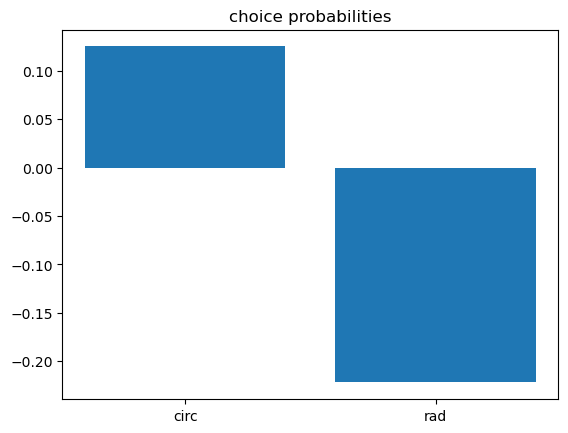

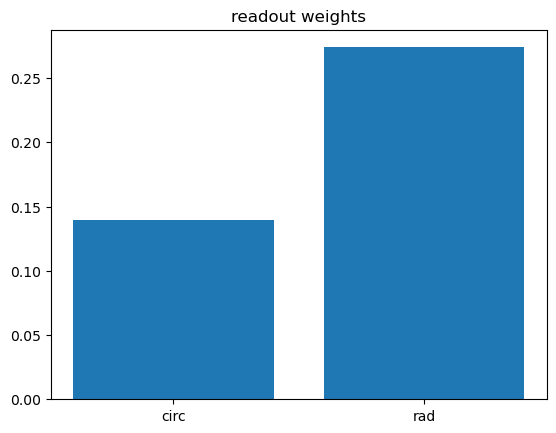

In [76]:
ind_rad = np.where(np.array(tuning_list_) <-0.1)[0]
ind_circ = np.where(np.array(tuning_list_) >0.1)[0]

#plt.bar(["circ", "rad"], [cp_list_[ind_circ].mean()-0.5, cp_list_[ind_rad].mean()-0.5])
plt.bar(["circ", "rad"], [cp_list_[ind_circ].mean()-0.5, 1-cp_list_[ind_rad].mean()-0.5])
plt.title("choice probabilities")

plt.figure()
plt.bar(["circ", "rad"], [rw_list_[ind_circ].mean(), rw_list_[ind_rad].mean()])
plt.title("readout weights")


In [ ]:
tunings[0], tunings[1], tuning_list_, ind_circ, ind_rad, cp_list

In [ ]:
cp_list_[ind_circ].mean(), cp_list_[ind_rad].mean()

In [ ]:
cp_sessions = [cp_list[i].mean() for i in range(len(cp_list))]
plt.plot(np.arange(1,n_sessions+1), np.array(cp_sessions)-0.5, "*-")

In [ ]:
cp_session_circ_long_list = []
cp_session_circ_means = []
for i in range(len(cp_session_circ)):
    cp_session_circ_long_list += list(cp_session_circ[i])
    if list(cp_session_circ[i]) != []:
        cp_session_circ_means.append(cp_session_circ[i].mean())

plt.figure()
plt.plot(np.array(cp_session_circ_long_list)-0.5, "*-")
plt.xlabel("sessions")
plt.ylabel("choice probabilties (circular tuning)")

plt.figure()
plt.plot(np.array(cp_session_circ_means)-0.5, "*-")
plt.xlabel("sessions")
plt.ylabel("choice probabilties")

cp_session_rad_long_list = []
cp_session_rad_means = []
for i in range(len(cp_session_rad)):
    cp_session_rad_long_list += list(cp_session_rad[i])
    if list(cp_session_rad[i]) != []:
        cp_session_rad_means.append(cp_session_rad[i].mean())

plt.figure()
plt.plot(1-np.array(cp_session_rad_long_list)-0.5, "*-")
plt.xlabel("sessions")
plt.ylabel("cp")

plt.figure()
plt.plot(1-np.array(cp_session_rad_means)-0.5, "*-")
plt.xlabel("sessions")
plt.ylabel("choice probabilties (radial tuning)")

In [ ]:
cp_session_pos_long_list = []
cp_session_pos_means = []
for i in range(len(cp_session_pos_tuning)):
    cp_session_pos_long_list += list(cp_session_pos_tuning[i])
    if list(cp_session_pos_tuning[i]) != []:
        cp_session_pos_means.append(cp_session_pos_tuning[i].mean())

plt.figure()
plt.plot(np.array(cp_session_pos_long_list)-0.5, "*-")
plt.xlabel("neurons x sessions")
plt.ylabel("choice probability (positive tuning)")

plt.figure()
plt.plot(np.array(cp_session_pos_means)-0.5, "*-")
plt.xlabel("sessions")
plt.ylabel("choice probability (positive tuning)")

cp_session_neg_long_list = []
cp_session_neg_means = []
for i in range(len(cp_session_neg_tuning)):
    cp_session_neg_long_list += list(cp_session_neg_tuning[i])
    if list(cp_session_neg_tuning[i]) != []:
        cp_session_neg_means.append(cp_session_neg_tuning[i].mean())

plt.figure()
plt.plot(np.array(cp_session_neg_long_list)-0.5, "*-")
plt.xlabel("neurons x sessions")
plt.ylabel("choice probability (negative tuning)")

plt.figure()
plt.plot(1-np.array(cp_session_neg_means)-0.5, "*-")
plt.xlabel("sessions")
plt.ylabel("choice probability (negative tuning)")

In [ ]:
plt.figure()
plt.plot(np.array(cp_session_pos_means)-0.5, "*-")
plt.xlabel("sessions")
plt.ylabel("choice probability (positive tuning)")


In [ ]:
cp_session_pos_tuning

In [ ]:
cp_session_neg_tuning